# Injury Risk Prediction — Logistic Regression Model
**Target:** `injury_risk` (0 = Safe, 1 = Injured)  
**Selected Features (8):** matches_last_7_days, previous_injury_count, fatigue_index, training_load, recovery_time, minutes_played, overall_rating, ball_control

---
## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

df = pd.read_csv("cleaned_player_data_logistic_reg_outliers_removed.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (8714, 18)


,potential,ball_control,dribbling,stamina,reactions,balance,strength,acceleration,age,attacking_work_rate_encoded,defensive_work_rate_encoded,fatigue_index,matches_last_7_days,minutes_played,recovery_time,previous_injury_count,training_load,injury_risk
0,71.0,49.0,51.0,54.0,47.0,65.0,76.0,60.0,34,2,2,65.9,1,1722,46.4,1,4.8,0
1,76.0,71.0,73.0,79.0,67.0,90.0,56.0,79.0,36,0,2,40.7,1,2566,42.0,1,6.6,0
2,67.0,67.0,66.0,66.0,51.0,92.0,71.0,77.0,35,2,2,47.8,2,1815,43.1,2,3.1,0
3,77.0,79.0,78.0,75.0,80.0,72.0,65.0,75.0,40,2,2,48.0,3,3192,38.8,3,8.3,1
4,74.0,63.0,54.0,68.0,61.0,80.0,59.0,69.0,30,2,0,50.9,3,2029,47.2,1,4.8,0


---
## 2. Select Important Features & Define X, y

In [2]:
# 8 important features selected from EDA feature importance analysis
selected_features = [
    "matches_last_7_days",
    "previous_injury_count",
    "fatigue_index",
    "training_load",
    "recovery_time",
    "minutes_played",
    "potential",
    "ball_control",
]

X = df[selected_features]
y = df["injury_risk"]

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts().to_string()}")
print(f"Positive class ratio: {y.mean():.2%}")

Features shape: (8714, 8)
Target distribution:
injury_risk
0    6100
1    2614
Positive class ratio: 30.00%


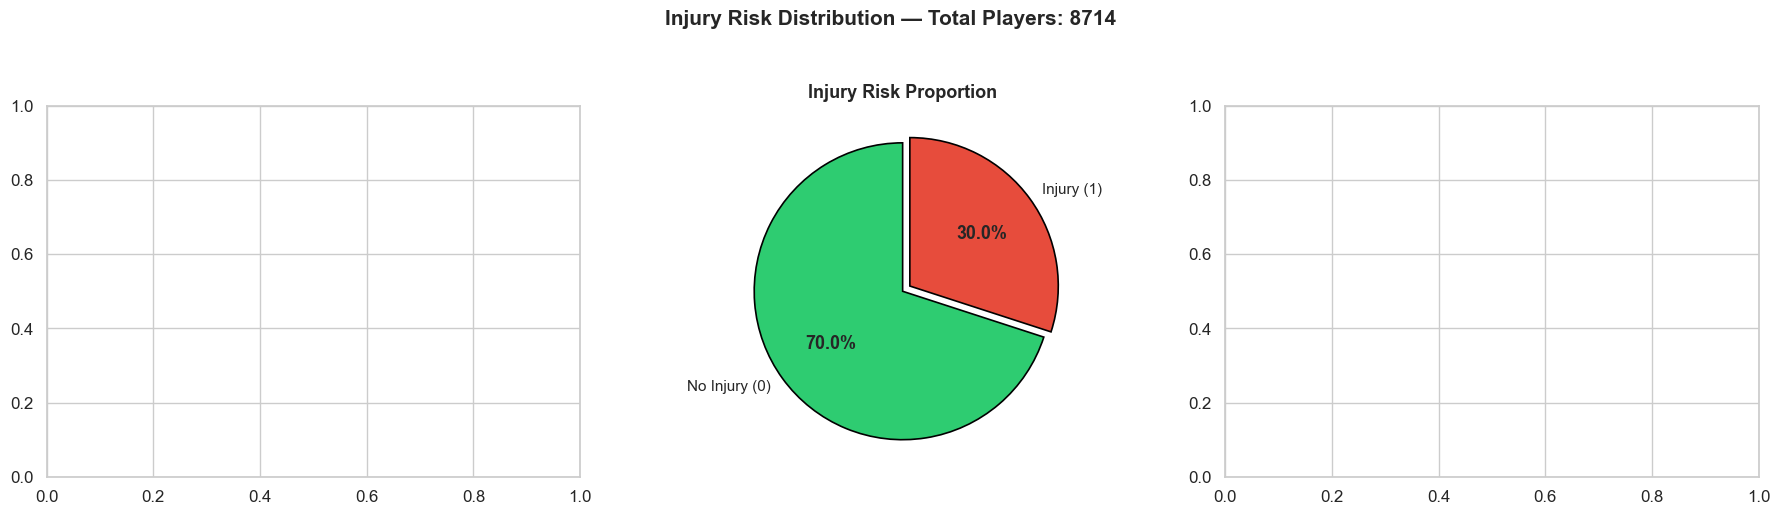

Total Players:     8714
No Injury (Safe):  6100  (70.0%)
Injury (At Risk):  2614  (30.0%)


In [3]:
# Injury Risk Proportion — Full Dataset
counts = y.value_counts().sort_index()
labels = ["No Injury (0)", "Injury (1)"]
colors = ["#2ecc71", "#e74c3c"]
total = len(y)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Bar Chart ---
# bars = axes[0].bar(labels, counts.values, color=colors, edgecolor="black", width=0.5)
# for bar, val in zip(bars, counts.values):
#     axes[0].text(bar.get_x() + bar.get_width()/2, val + 80,
#                  f"{val}\n({val/total*100:.1f}%)", ha="center", fontweight="bold", fontsize=12)
# axes[0].set_ylabel("Number of Players", fontsize=12)
# axes[0].set_title("Player Count by Injury Status", fontweight="bold", fontsize=13)

# --- Pie Chart ---
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels, colors=colors, autopct="%1.1f%%",
    startangle=90, explode=(0, 0.06), textprops={"fontsize": 11},
    wedgeprops={"edgecolor": "black", "linewidth": 1.2})
for at in autotexts:
    at.set_fontweight("bold")
    at.set_fontsize(13)
axes[1].set_title("Injury Risk Proportion", fontweight="bold", fontsize=13)

# --- Stacked Horizontal Bar (100%) ---
# axes[2].barh(["All Players"], counts.values[0], color=colors[0], edgecolor="black", label=labels[0])
# axes[2].barh(["All Players"], counts.values[1], left=counts.values[0], color=colors[1], edgecolor="black", label=labels[1])
# axes[2].text(counts.values[0]/2, 0, f"{counts.values[0]/total*100:.1f}%",
#              ha="center", va="center", fontweight="bold", fontsize=14, color="white")
# axes[2].text(counts.values[0] + counts.values[1]/2, 0, f"{counts.values[1]/total*100:.1f}%",
#              ha="center", va="center", fontweight="bold", fontsize=14, color="white")
# axes[2].set_xlabel("Number of Players", fontsize=12)
# axes[2].set_title("Proportion Breakdown (Stacked)", fontweight="bold", fontsize=13)
# axes[2].legend(fontsize=10, loc="lower right")

plt.suptitle(f"Injury Risk Distribution — Total Players: {total}", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print(f"Total Players:     {total}")
print(f"No Injury (Safe):  {counts.values[0]}  ({counts.values[0]/total*100:.1f}%)")
print(f"Injury (At Risk):  {counts.values[1]}  ({counts.values[1]/total*100:.1f}%)")

---
## 3. Train-Test Split (80/20, Stratified)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows ({y_train.mean():.2%} positive)")
print(f"Test set:     {X_test.shape[0]} rows ({y_test.mean():.2%} positive)")

Training set: 6971 rows (30.00% positive)
Test set:     1743 rows (30.01% positive)


---
## 4. Feature Scaling — Column-wise (Right Scaler per Feature)
Different features need different scalers based on their distribution:
- **StandardScaler** — near-normal features (fatigue_index, training_load, recovery_time, minutes_played, overall_rating, ball_control)
- **MinMaxScaler** — bounded discrete features (matches_last_7_days: 1-3)
- **RobustScaler** — features with outliers (previous_injury_count: 9.12% outliers)

In [5]:
# Define feature groups by distribution type
standard_cols = ["fatigue_index", "training_load", "recovery_time",
                 "minutes_played", "potential", "ball_control"]
minmax_cols   = ["matches_last_7_days"]
robust_cols   = ["previous_injury_count"]

# ColumnTransformer applies the right scaler to each group
scaler = ColumnTransformer([
    ("standard", StandardScaler(), standard_cols),
    ("minmax",   MinMaxScaler(),   minmax_cols),
    ("robust",   RobustScaler(),   robust_cols),
], remainder="drop")

# Fit ONLY on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Column order after transform: standard_cols + minmax_cols + robust_cols
all_scaled_cols = standard_cols + minmax_cols + robust_cols

# Show before vs after comparison
before_df = X_train[all_scaled_cols]
after_df  = pd.DataFrame(X_train_scaled, columns=all_scaled_cols)

comparison = pd.DataFrame({
    "Feature": all_scaled_cols,
    "Scaler": (["StandardScaler"]*len(standard_cols) +
               ["MinMaxScaler"]*len(minmax_cols) +
               ["RobustScaler"]*len(robust_cols)),
    "Before Mean": before_df.mean().round(2).values,
    "Before Std":  before_df.std().round(2).values,
    "Before Min":  before_df.min().round(2).values,
    "Before Max":  before_df.max().round(2).values,
    "After Mean":  after_df.mean().round(4).values,
    "After Std":   after_df.std().round(4).values,
    "After Min":   after_df.min().round(4).values,
    "After Max":   after_df.max().round(4).values,
})
print("Before vs After Scaling (column-wise):\n")
comparison

Before vs After Scaling (column-wise):



,Feature,Scaler,Before Mean,Before Std,Before Min,Before Max,After Mean,After Std,After Min,After Max
0,fatigue_index,StandardScaler,50.03,13.99,0.0,100.0,-0.0000,1.0001,-3.5767,3.5718
1,training_load,StandardScaler,5.85,1.36,1.5,10.0,-0.0000,1.0001,-3.1988,3.0465
2,recovery_time,StandardScaler,42.87,7.50,18.7,72.0,-0.0000,1.0001,-3.2237,3.8844
3,minutes_played,StandardScaler,2520.30,573.10,900.0,4485.0,-0.0000,1.0001,-2.8274,3.4284
4,potential,StandardScaler,71.37,5.93,55.0,87.0,-0.0000,1.0001,-2.7632,2.6371
5,ball_control,StandardScaler,66.80,8.38,37.0,90.0,-0.0000,1.0001,-3.5579,2.7705
6,matches_last_7_days,MinMaxScaler,1.87,0.73,1.0,3.0,0.4358,0.3640,0.0000,1.0000
7,previous_injury_count,RobustScaler,1.64,1.27,0.0,5.0,0.6419,1.2678,-1.0000,4.0000


---
## 5. Train Logistic Regression Model

In [6]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Model trained successfully!")
print(f"Training Accuracy: {model.score(X_train_scaled, y_train):.4f}")
print(f"Test Accuracy:     {accuracy_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC:      {roc_auc_score(y_test, y_prob):.4f}")

Model trained successfully!
Training Accuracy: 0.8531
Test Accuracy:     0.8738
Test ROC-AUC:      0.9320


---
## 6. Cross-Validation (5-Fold Stratified)

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline ensures scaling is done inside each fold (no data leakage)
cv_scaler = ColumnTransformer([
    ("standard", StandardScaler(), standard_cols),
    ("minmax",   MinMaxScaler(),   minmax_cols),
    ("robust",   RobustScaler(),   robust_cols),
], remainder="drop")

pipe = Pipeline([
    ("scaler", cv_scaler),
    ("model",  LogisticRegression(max_iter=1000, random_state=42))
])

cv_accuracy = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
cv_roc = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")

print("5-Fold Cross-Validation Results:\n")
print(f"  Accuracy per fold: {cv_accuracy.round(4)}")
print(f"  Mean Accuracy:     {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})")
print(f"\n  ROC-AUC per fold:  {cv_roc.round(4)}")
print(f"  Mean ROC-AUC:      {cv_roc.mean():.4f} (+/- {cv_roc.std():.4f})")

5-Fold Cross-Validation Results:

  Accuracy per fold: [0.8577 0.856  0.8531 0.8635 0.8536]
  Mean Accuracy:     0.8568 (+/- 0.0037)

  ROC-AUC per fold:  [0.9219 0.9223 0.9162 0.9211 0.9219]
  Mean ROC-AUC:      0.9207 (+/- 0.0023)


---
## 7. Classification Report

In [8]:
print("Classification Report (Test Set):\n")
print(classification_report(y_test, y_pred, target_names=["Safe (0)", "Injured (1)"]))

Classification Report (Test Set):

              precision    recall  f1-score   support

    Safe (0)       0.90      0.93      0.91      1220
 Injured (1)       0.81      0.75      0.78       523

    accuracy                           0.87      1743
   macro avg       0.85      0.84      0.85      1743
weighted avg       0.87      0.87      0.87      1743



---
## 8. Confusion Matrix

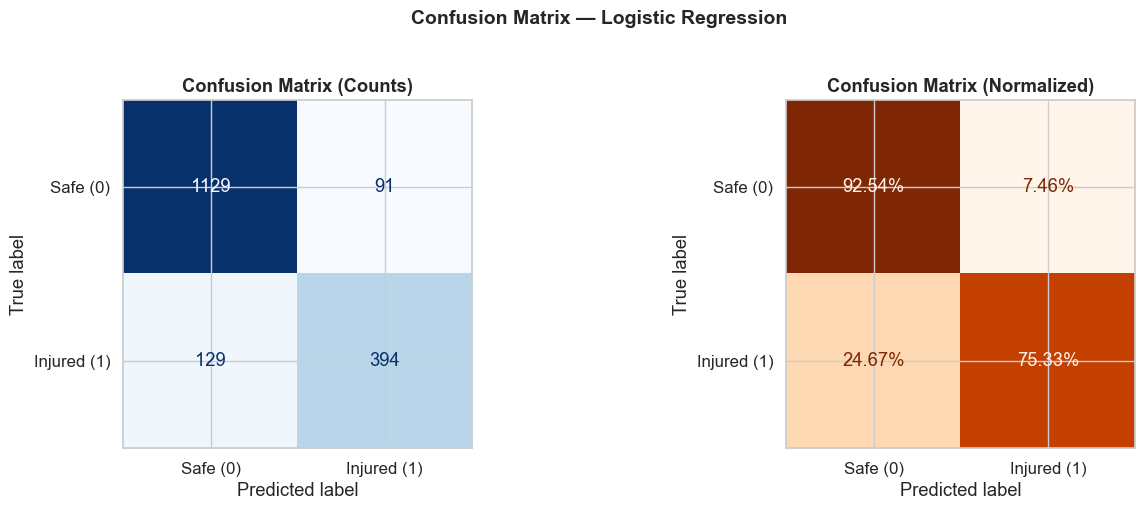

True Negatives:  1129  |  False Positives: 91
False Negatives: 129  |  True Positives:  394


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Safe (0)", "Injured (1)"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix (Counts)", fontweight="bold")

# Normalized (percentages)
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")
ConfusionMatrixDisplay(cm_norm, display_labels=["Safe (0)", "Injured (1)"]).plot(
    ax=axes[1], cmap="Oranges", colorbar=False, values_format=".2%")
axes[1].set_title("Confusion Matrix (Normalized)", fontweight="bold")

plt.suptitle("Confusion Matrix — Logistic Regression", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}  |  False Positives: {fp}")
print(f"False Negatives: {fn}  |  True Positives:  {tp}")

---
## 9. ROC Curve & AUC Score

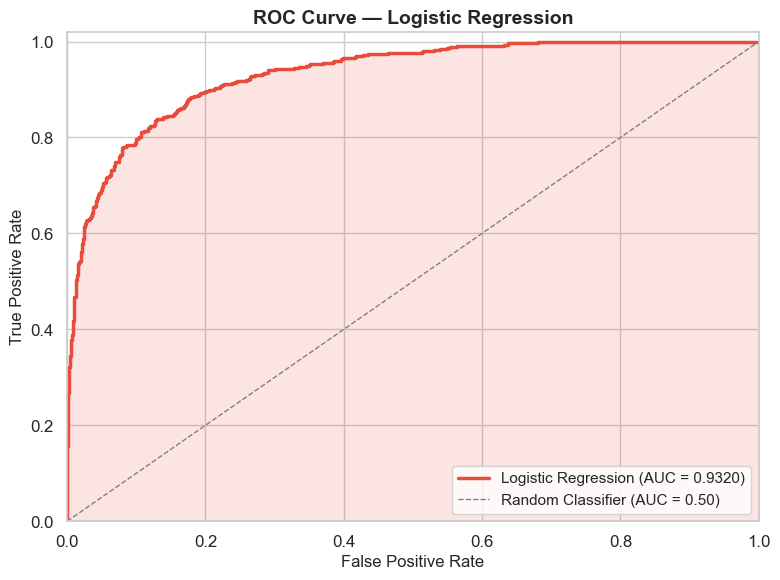

In [10]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="#e74c3c", linewidth=2.5, label=f"Logistic Regression (AUC = {auc_score:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random Classifier (AUC = 0.50)")
ax.fill_between(fpr, tpr, alpha=0.15, color="#e74c3c")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — Logistic Regression", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

---
## 10. Precision-Recall Curve

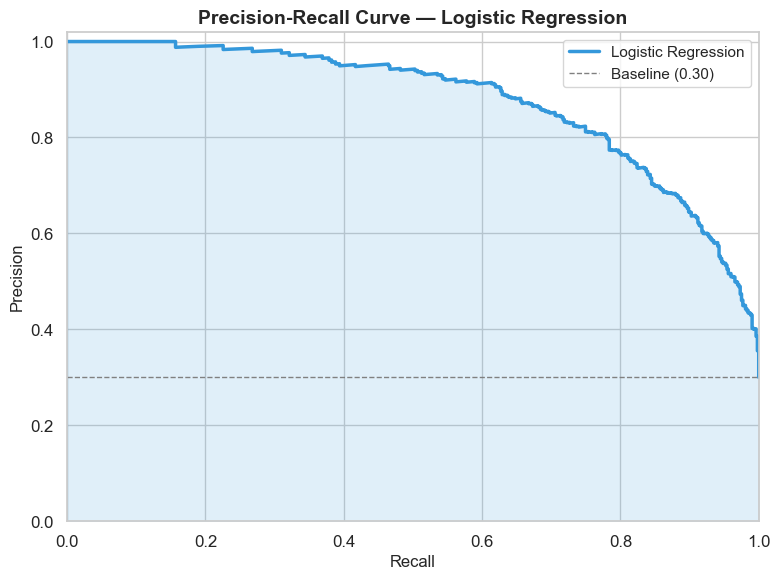

In [11]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color="#3498db", linewidth=2.5, label="Logistic Regression")
ax.axhline(y=y_test.mean(), color="gray", linestyle="--", linewidth=1, label=f"Baseline ({y_test.mean():.2f})")
ax.fill_between(recall, precision, alpha=0.15, color="#3498db")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve — Logistic Regression", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="upper right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

---
## 11. Model Coefficients — Feature Impact

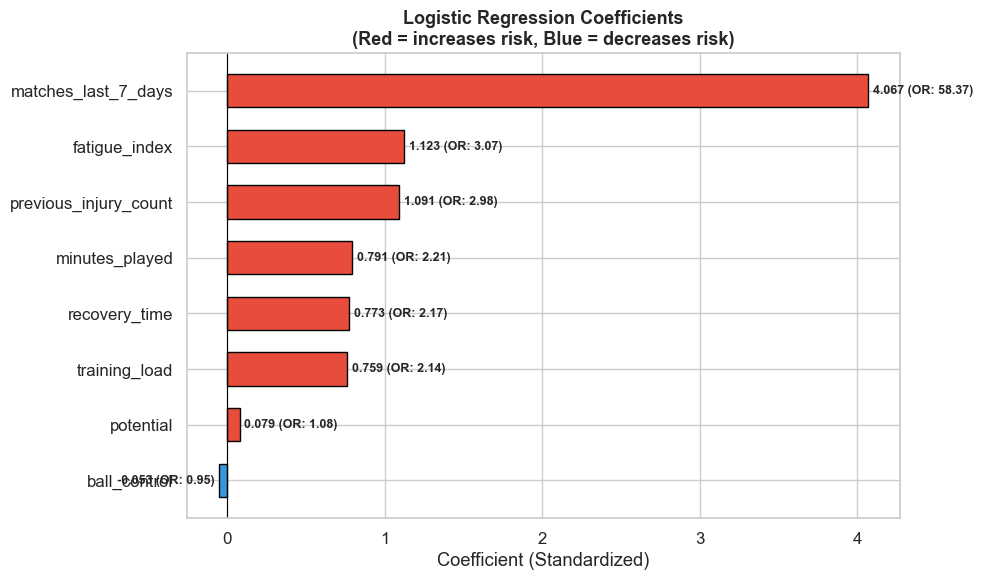

Interpretation: Odds Ratio > 1 means higher value increases injury risk
                Odds Ratio < 1 means higher value decreases injury risk

              Feature  Coefficient  Odds Ratio
  matches_last_7_days     4.066785   58.369018
        fatigue_index     1.123303    3.074995
previous_injury_count     1.090869    2.976861
       minutes_played     0.790880    2.205337
        recovery_time     0.773231    2.166755
        training_load     0.759146    2.136450
            potential     0.079051    1.082259
         ball_control    -0.052803    0.948566


In [12]:
coef_df = pd.DataFrame({
    "Feature": all_scaled_cols,
    "Coefficient": model.coef_[0],
    "Abs_Coefficient": np.abs(model.coef_[0]),
    "Odds Ratio": np.exp(model.coef_[0])
}).sort_values("Abs_Coefficient", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c" if c > 0 else "#3498db" for c in coef_df["Coefficient"]]
bars = ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="black", height=0.6)

for bar, val, odds in zip(bars, coef_df["Coefficient"], coef_df["Odds Ratio"]):
    offset = 0.03 if val >= 0 else -0.03
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:.3f} (OR: {odds:.2f})", va="center", ha=ha, fontweight="bold", fontsize=9)

ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (Standardized)")
ax.set_title("Logistic Regression Coefficients\n(Red = increases risk, Blue = decreases risk)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Interpretation: Odds Ratio > 1 means higher value increases injury risk")
print("                Odds Ratio < 1 means higher value decreases injury risk\n")
print(coef_df.sort_values("Abs_Coefficient", ascending=False)[["Feature", "Coefficient", "Odds Ratio"]].to_string(index=False))

---
## 12. Model Summary

In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score

summary = {
    "Metric": ["Training Accuracy", "Test Accuracy", "ROC-AUC Score",
               "Precision (Injured)", "Recall (Injured)", "F1-Score (Injured)",
               "CV Mean Accuracy (5-fold)", "CV Mean ROC-AUC (5-fold)"],
    "Value": [
        f"{model.score(X_train_scaled, y_train):.4f}",
        f"{accuracy_score(y_test, y_pred):.4f}",
        f"{roc_auc_score(y_test, y_prob):.4f}",
        f"{precision_score(y_test, y_pred):.4f}",
        f"{recall_score(y_test, y_pred):.4f}",
        f"{f1_score(y_test, y_pred):.4f}",
        f"{cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})",
        f"{cv_roc.mean():.4f} (+/- {cv_roc.std():.4f})",
    ]
}

summary_df = pd.DataFrame(summary)
print("=" * 55)
print("    LOGISTIC REGRESSION — MODEL SUMMARY")
print("=" * 55)
print(summary_df.to_string(index=False))
print("=" * 55)

    LOGISTIC REGRESSION — MODEL SUMMARY
                   Metric               Value
        Training Accuracy              0.8531
            Test Accuracy              0.8738
            ROC-AUC Score              0.9320
      Precision (Injured)              0.8124
         Recall (Injured)              0.7533
       F1-Score (Injured)              0.7817
CV Mean Accuracy (5-fold) 0.8568 (+/- 0.0037)
 CV Mean ROC-AUC (5-fold) 0.9207 (+/- 0.0023)


In [ ]:
import joblib
joblib.dump(model, './models/injury_model.pkl')
joblib.dump(scaler, './models/injury_scaler.pkl')
print("Injury model and scaler saved!")

Injury model and scaler saved!


: 